隨機產生線性回歸資料集，loss-function使用MSE，最佳化參數是可以直接用公式表達，利用正規表達式

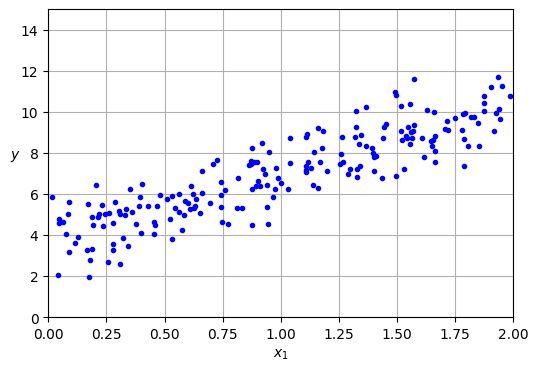

In [16]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed = 42)
m = 200
X = 2*rng.random((m,1))
y = 4+3*X+rng.standard_normal((m,1))


#把隨機產生的真實資料畫出來
plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([0, 2, 0, 15])
plt.grid()

plt.show()

In [17]:
from sklearn.preprocessing import add_dummy_feature

X_b = add_dummy_feature(X)
parameter_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
print(parameter_best)

[[3.69084138]
 [3.32960458]]


根據我們模型，4跟3才是完美值，擬合產出的資料集的值，現在我們找到最小化MSE的parameter，現在可以用這個best_parameter做預測

Text(0, 0.5, '$y$')

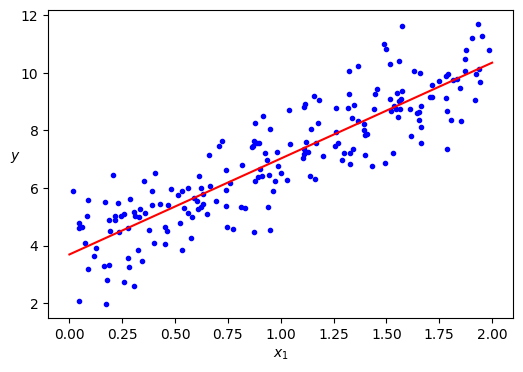

In [18]:
X_test = np.array([[0],[2]])
X_test_b = add_dummy_feature(X_test)#補1，用線性代數處理線性模型
y_predict = X_test_b @ parameter_best

#畫畫看:)
plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.plot(X_test, y_predict, "r-")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)

上述的事情可以用套件完成，這樣:)

In [19]:
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
print(lin_reg.intercept_, lin_reg.coef_)

"""
X = 2*rng.random((m,1))
y = 4+3*X+rng.standard_normal((m,1))
"""

[3.69084138] [[3.32960458]]


'\nX = 2*rng.random((m,1))\ny = 4+3*X+rng.standard_normal((m,1))\n'

# 梯度下降


---
梯度下降就是為了讓成本最小化而不斷調整參數，測量一個誤差函數相對於參數向量$\theta$，他會測量誤差函數相對於$\theta$的局部梯度，梯度為0代表達到最小值，通常會一開始把$\theta$設成隨機值，一次會走一小步，直到收斂到一個最小值，步長的大小是梯度下降的叫做learning rate的參數，太小會造成時間複雜度不好，太大很能會錯過答案，另外，有可能要考慮全域最小值的問題，有可能會找到局部最小值就停下來了。


**批次梯度下降**


---


大部分的模型的參數是好多個，為了實作出梯度下降，需要計算成本函數相對於每一個模型參數$\theta$j的梯度，叫做偏微分

[[3.69084138]
 [3.32960458]]


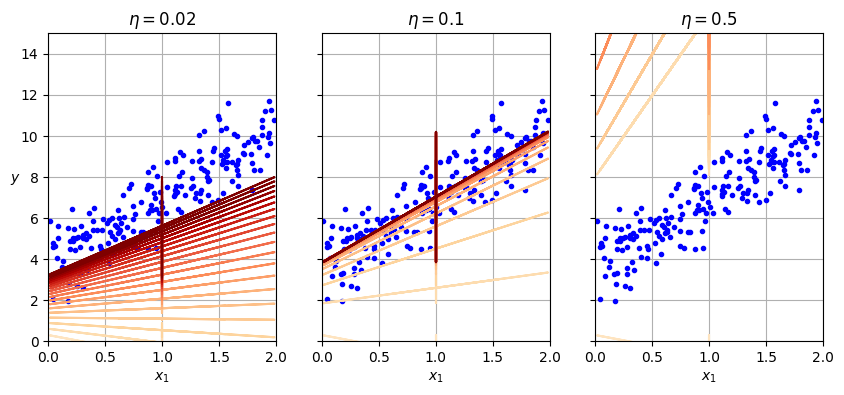

In [20]:
#"""
learning_rate = 0.1
n_epochs = 1000;
m = len(X_b)#X_b為200*1的矩陣

rng = np.random.default_rng(seed = 42)
theta = rng.standard_normal((2,1))#2*1

for epoch in range(n_epochs):
  gradients = 2/m * X_b.T.dot(X_b.dot(theta)-y)
  theta = theta - learning_rate * gradients

print(theta)
#"""
#"""
#extra code – generates Figure 4–8 by Aurelien Geron
import matplotlib as mpl

def plot_gradient_descent(theta, eta):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_epochs = 1000
    n_shown = 20
    theta_path = []
    for epoch in range(n_epochs):
        if epoch < n_shown:
            y_predict = X_b @ theta
            color = mpl.colors.rgb2hex(plt.cm.OrRd(epoch / n_shown + 0.15))
            plt.plot(X_b, y_predict, linestyle="solid", color=color)
        gradients = 2 / m * X_b.T @ (X_b @ theta - y)
        theta = theta - eta * gradients
        theta_path.append(theta)
    plt.xlabel("$x_1$")
    plt.axis([0, 2, 0, 15])
    plt.grid()
    plt.title(fr"$\eta = {eta}$")
    return theta_path

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2, 1))  # randomly initialized model parameters

plt.figure(figsize=(10, 4))
plt.subplot(131)
plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0)
plt.subplot(132)
theta_path_bgd = plot_gradient_descent(theta, eta=0.1)
plt.gca().axes.yaxis.set_ticklabels([])
plt.subplot(133)
plt.gca().axes.yaxis.set_ticklabels([])
plot_gradient_descent(theta, eta=0.5)

plt.show()
#"""

這裡會會衍生另外一個問題，會不知道epoch怎麼設定才是最好的，可以把epoch設定的很大，在梯度向量變得很小的時候中斷算法

**隨機梯度下降**


------

每次會在訓練集隨機選擇一個實例，只使用那個實例來計算梯度，可以使用巨大的訓練集做訓練，因為隨機，不會順滑的下降，比起梯度下降可以更快地找到最小值，但是無法永遠在最小值穩定下來，所以我們需要根據學習排程來慢慢降低學習率


In [21]:
n_epochs = 50
t0,t1 = 5,50

def learning_schedule(t):
  return t0/(t+t1)

rng = np.random.default_rng(seed = 42)
theta = rng.standard_normal((2,1))

for epoch in range(n_epochs):
  for iteration in range(m):
    random_index = rng.integers(m)
    xi = X_b[random_index:random_index+1]
    yi = y[random_index:random_index+1]
    gradients = 2 * xi.T @ (xi @ theta - yi)
    learning_rate =  learning_schedule(epoch*m+iteration)
    theta = theta - learning_rate * gradients

print(theta);

[[3.69826475]
 [3.30748311]]


**多項式回歸**


---
資料有時會比一條線更複雜，deep learning已經可以用Relu擬和非線性資料了(simon prince - <'Understanding deep learning'>)，機器學習的作法是把每一個特徵的次方當成新的特徵，並且加入時使用這個擴充的特徵集合來訓練一個線性模型




---
產生非線性的隨機資料


---



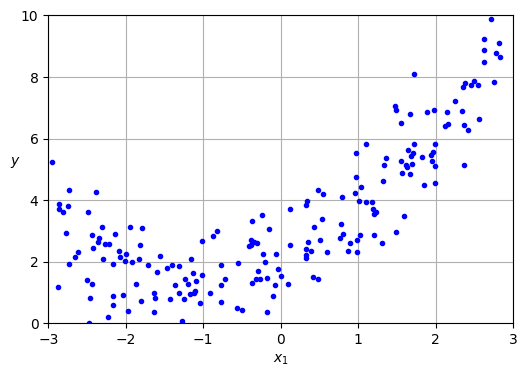

In [22]:
rng = np.random.default_rng(seed=42)
m = 200
X = 6 * rng.random((m, 1)) - 3
y = 0.5 * X ** 2 + X + 2 + rng.standard_normal((m, 1))

plt.figure(figsize=(6, 4))
plt.plot(X, y, "b.")
plt.xlabel("$x_1$")
plt.ylabel("$y$", rotation=0)
plt.axis([-3, 3, 0, 10])
plt.grid()

plt.show()

In [23]:

#使用Poly套件增加多項回歸需要的特徵
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree = 2,include_bias = False)
X_poly = poly.fit_transform(X)
print(X[0])
print(X_poly[0])

#使用特徵做regression
lin_reg = LinearRegression()
lin_reg.fit(X_poly,y)
print(lin_reg.intercept_,lin_reg.coef_)

[1.64373629]
[1.64373629 2.701869  ]
[2.00540719] [[1.11022126 0.50526985]]


**學習曲線**


---

高次多項式擬和線性資料的效果通常會比LinearRegression還要好，但問題是通常我們不會知道產生資料的函數長怎樣，怎麼判斷是過度擬和還是欠擬合?

可以使用k-fold來驗證，會給予分數，另外一種則是觀察學習曲線，把訓練誤差跟驗證誤差畫成迭代次數的函數，換句話說就是在過程中，定期用訓練集跟驗證集來評估模型，learning_cruve回傳以每一個大小，每一個交叉驗證fold來獲得的訓練分數跟驗證分數

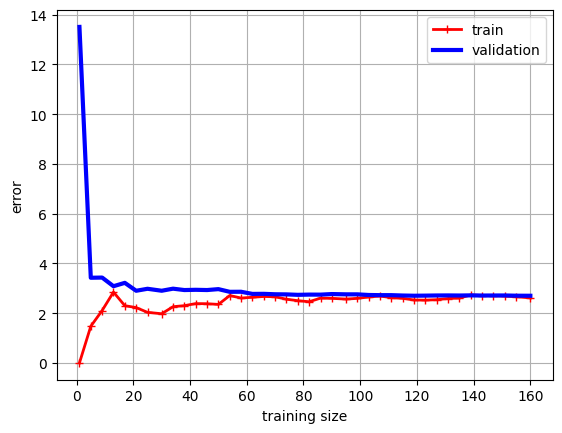

In [24]:
from sklearn.model_selection import learning_curve

train_sizes,train_scores,val_score = learning_curve(
    LinearRegression(),X,y,train_sizes = np.linspace(0.01,1.0,40)
    ,cv = 5,scoring = 'neg_mean_squared_error'
)

train_errors = -train_scores.mean(axis = 1)
val_errors = -val_score.mean(axis = 1)

plt.plot(train_sizes,train_errors,'r-+',linewidth = 2,label = 'train')
plt.plot(train_sizes,val_errors,'b-',linewidth = 3,label = 'validation')
plt.legend()
plt.xlabel('training size')
plt.ylabel('error')
plt.grid()
plt.show()

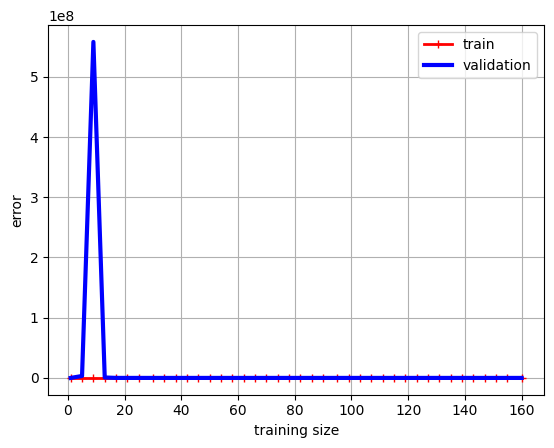

In [25]:
from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(
    PolynomialFeatures(degree = 10,include_bias = False),
    LinearRegression()
)

train_sizes,train_scores,val_score = learning_curve(
    polynomial_regression,X,y,train_sizes = np.linspace(0.01,1.0,40)
    ,cv = 5,scoring = 'neg_mean_squared_error'
)

train_errors = -train_scores.mean(axis = 1)
val_errors = -val_score.mean(axis = 1)

plt.plot(train_sizes,train_errors,'r-+',linewidth = 2,label = 'train')
plt.plot(train_sizes,val_errors,'b-',linewidth = 3,label = 'validation')
plt.legend()
plt.xlabel('training size')
plt.ylabel('error')
plt.grid()
plt.show()

# logistic Regression

---

如果需要估計某個實例屬於特定類別的機率，就可以使用logistic回歸，如果預測出來大於某個閥值，那麼就會歸類為陽性，否則就是陰性，所以logistic可以算一個二元分類器

In [26]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
list(iris)#回傳key

['data',
 'target',
 'frame',
 'target_names',
 'DESCR',
 'feature_names',
 'filename',
 'data_module']

In [27]:
iris.data.head(3)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2


In [28]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [29]:
iris.target.head(3)

,target
0,0
1,0
2,0


In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

X = iris.data["petal width (cm)"].values.reshape(-1,1)
Y = iris.target_names[iris.target] == "virginica"
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,random_state = 42)

log_reg = LogisticRegression(random_state = 42)
log_reg.fit(X_train,Y_train)

LogisticRegression(random_state=42)

機率閥值為:1.6516516516516517


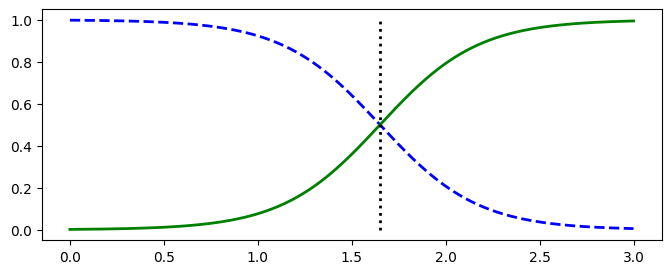

In [31]:
#查看花瓣長度0到3cm之間的花朵估計出來的機率
import numpy as np
import matplotlib.pyplot as plt
X2 = np.linspace(0,3,1000).reshape(-1,1)
Y_prob = log_reg.predict_proba(X2)
decision_boundary = X2[Y_prob[:,1] >= 0.5][0,0]

print("機率閥值為:"+decision_boundary.__str__())

plt.figure(figsize=(8, 3))  # extra code – not needed, just formatting
plt.plot(X2, Y_prob[:, 0], "b--", linewidth=2,
         label="Not Iris virginica proba")
plt.plot(X2, Y_prob[:, 1], "g-", linewidth=2, label="Iris virginica proba")
plt.plot([decision_boundary, decision_boundary], [0, 1], "k:", linewidth=2,
         label="Decision boundary")

**SoftMax Regression**


---


logistic模型可以做一般化，可以直接預測多個類別，當吃進一個實例，先為每一個類別k計算一個分數$S_{k}$(x)，在套用softmax函數估計各個類別的機率

In [38]:
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
Y = iris["target"]
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,random_state = 42)

softmax_reg = LogisticRegression(C = 30,random_state = 42)
softmax_reg.fit(X_train,Y_train)

LogisticRegression(C=30, random_state=42)

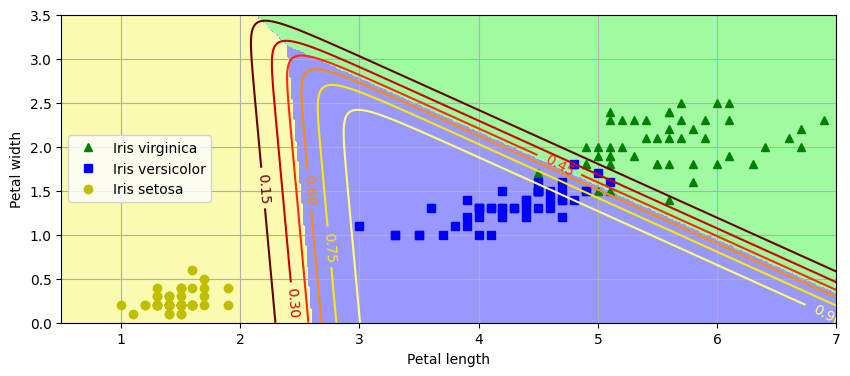

In [39]:
# extra code – this cell generates Figure 4–25

from matplotlib.colors import ListedColormap

custom_cmap = ListedColormap(["#fafab0", "#9898ff", "#a0faa0"])

x0, x1 = np.meshgrid(np.linspace(0, 8, 500).reshape(-1, 1),
                     np.linspace(0, 3.5, 200).reshape(-1, 1))
X_new = np.c_[x0.ravel(), x1.ravel()]

y_proba = softmax_reg.predict_proba(X_new)
y_predict = softmax_reg.predict(X_new)

zz1 = y_proba[:, 1].reshape(x0.shape)
zz = y_predict.reshape(x0.shape)

plt.figure(figsize=(10, 4))
plt.plot(X[Y == 2, 0], X[Y == 2, 1], "g^", label="Iris virginica")
plt.plot(X[Y == 1, 0], X[Y == 1, 1], "bs", label="Iris versicolor")
plt.plot(X[Y == 0, 0], X[Y == 0, 1], "yo", label="Iris setosa")

plt.contourf(x0, x1, zz, cmap=custom_cmap)
contour = plt.contour(x0, x1, zz1, cmap="hot")
plt.clabel(contour, inline=1)
plt.xlabel("Petal length")
plt.ylabel("Petal width")
plt.legend(loc="center left")
plt.axis([0.5, 7, 0, 3.5])
plt.grid()

plt.show()